In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('titanic')


df.to_csv("titanic.csv", index=False)

print("Titanic dataset loaded and saved successfully.")
print("Shape:", df.shape)

print("\nDataset Info:")
df.info()

print("\nDescriptive Statistics:")
display(df.describe(include="all"))

print("\nMissing-value percentages:")
missing_pct = (df.isna().mean() * 100)
display(missing_pct[missing_pct > 0].sort_values(ascending=False))

Titanic dataset loaded and saved successfully.
Shape: (891, 15)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Missing-value percentages:


,0
deck,77.216611
age,19.865320
embarked,0.224467
embark_town,0.224467


In [2]:



df = df.drop(columns=["deck"])


df["age"] = df["age"].fillna(df["age"].median())


df = df.dropna(subset=["embarked"])


df = df.drop(columns=["embark_town"])

print("Missing-value handling completed.")
print("\nRemaining missing values:")
print(df.isna().sum())

print("\nCleaned dataset shape:")
print(df.shape)

Missing-value handling completed.

Remaining missing values:
survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
class         0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

Cleaned dataset shape:
(889, 13)


In [3]:

Q1_age = df["age"].quantile(0.25)
Q3_age = df["age"].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age

age_outliers = df[
    (df["age"] < lower_age) | (df["age"] > upper_age)
]


Q1_fare = df["fare"].quantile(0.25)
Q3_fare = df["fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare

fare_outliers = df[
    (df["fare"] < lower_fare) | (df["fare"] > upper_fare)
]


fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print("AGE IQR OUTLIER ANALYSIS")
print("Q1:", Q1_age)
print("Q3:", Q3_age)
print("IQR:", IQR_age)
print("Lower Bound:", lower_age)
print("Upper Bound:", upper_age)
print("Number of Age Outliers:", len(age_outliers))

print("\nFARE IQR OUTLIER ANALYSIS")
print("Q1:", Q1_fare)
print("Q3:", Q3_fare)
print("IQR:", IQR_fare)
print("Lower Bound:", lower_fare)
print("Upper Bound:", upper_fare)
print("Number of Fare Outliers:", len(fare_outliers))

print("\nFARE STATISTICS")
print("Mean:", fare_mean)
print("Median:", fare_median)
print("Mode:", fare_mode)


if fare_mean > fare_median > fare_mode:
    print("\nFare distribution: RIGHT-SKEWED")
elif fare_mean < fare_median < fare_mode:
    print("\nFare distribution: LEFT-SKEWED")
else:
    print("\nFare distribution: approximately SYMMETRIC / not strictly ordered")

AGE IQR OUTLIER ANALYSIS
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower Bound: 2.5
Upper Bound: 54.5
Number of Age Outliers: 65

FARE IQR OUTLIER ANALYSIS
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower Bound: -26.7605
Upper Bound: 65.6563
Number of Fare Outliers: 114

FARE STATISTICS
Mean: 32.09668087739032
Median: 14.4542
Mode: 8.05

Fare distribution: RIGHT-SKEWED


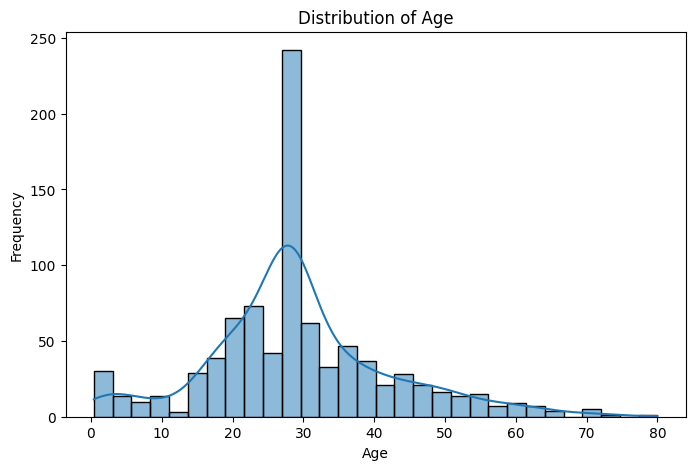

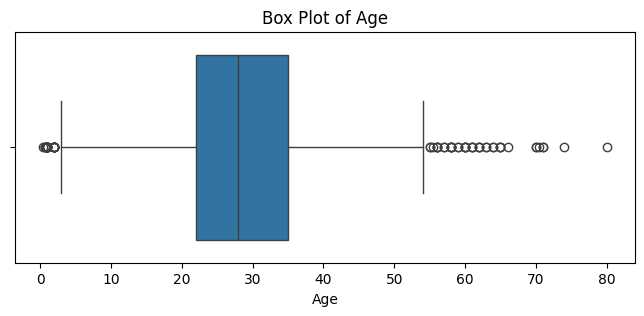

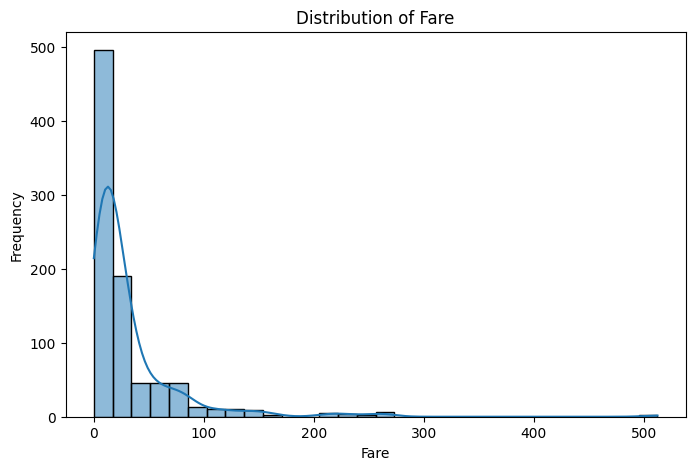

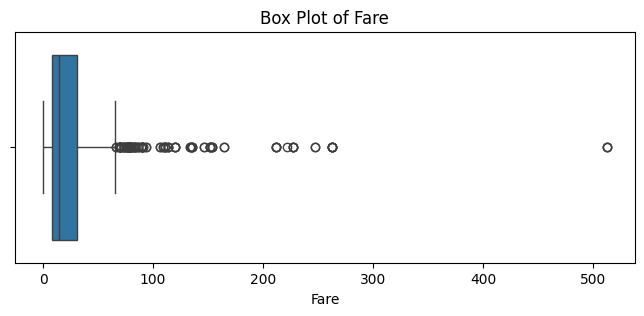

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 3))
sns.boxplot(x=df["age"])
plt.title("Box Plot of Age")
plt.xlabel("Age")
plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(df["fare"], bins=30, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(8, 3))
sns.boxplot(x=df["fare"])
plt.title("Box Plot of Fare")
plt.xlabel("Fare")
plt.show()

In [6]:



sex_survival = df.groupby("sex")["survived"].mean() * 100

print("Survival Rate by Sex:")
print(sex_survival.round(2))



pclass_survival = df.groupby("pclass")["survived"].mean() * 100

print("\nSurvival Rate by Pclass:")
print(pclass_survival.round(2))




groups = {}

for sex in df["sex"].unique():
    for pclass in sorted(df["pclass"].unique()):
        mask = (df["sex"] == sex) & (df["pclass"] == pclass)

        if mask.sum() > 0:
            survival_rate = df.loc[mask, "survived"].mean() * 100
            groups[(sex, pclass)] = survival_rate

print("\nSurvival Rate by Sex and Pclass:")

for group, rate in groups.items():
    print(f"Sex: {group[0]}, Pclass: {group[1]} -> {rate:.2f}%")

Survival Rate by Sex:
sex
female    74.04
male      18.89
Name: survived, dtype: float64

Survival Rate by Pclass:
pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64

Survival Rate by Sex and Pclass:
Sex: male, Pclass: 1 -> 36.89%
Sex: male, Pclass: 2 -> 15.74%
Sex: male, Pclass: 3 -> 13.54%
Sex: female, Pclass: 1 -> 96.74%
Sex: female, Pclass: 2 -> 92.11%
Sex: female, Pclass: 3 -> 50.00%


6x6 Correlation Matrix:


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


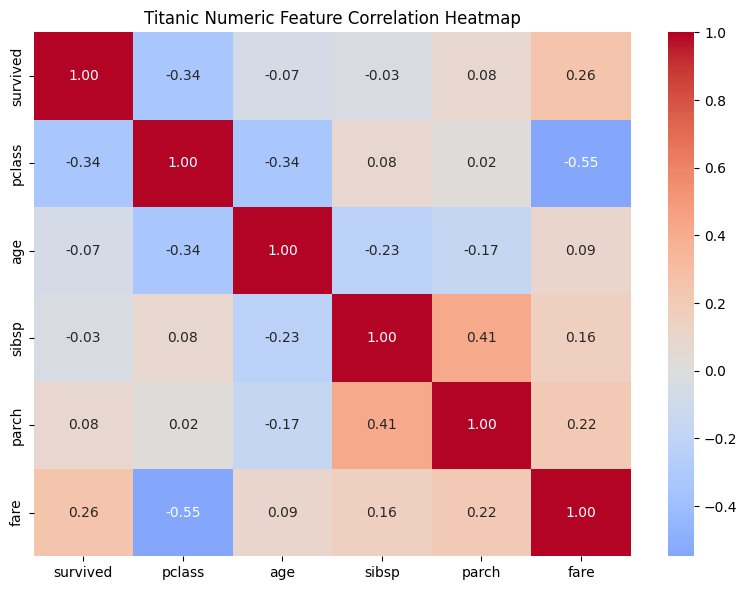

Two strongest correlations:
pclass vs fare: correlation = -0.548, absolute correlation = 0.548
sibsp vs parch: correlation = 0.415, absolute correlation = 0.415


In [7]:
corr_cols = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[corr_cols].corr()

print("6x6 Correlation Matrix:")
display(corr_matrix.round(3))


plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Titanic Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()



pairs = []

for i in range(len(corr_cols)):
    for j in range(i + 1, len(corr_cols)):
        value = corr_matrix.iloc[i, j]
        pairs.append((corr_cols[i], corr_cols[j], value, abs(value)))

pairs = sorted(pairs, key=lambda x: x[3], reverse=True)

print("Two strongest correlations:")

for pair in pairs[:2]:
    print(
        f"{pair[0]} vs {pair[1]}: "
        f"correlation = {pair[2]:.3f}, "
        f"absolute correlation = {pair[3]:.3f}"
    )

### Correlation Interpretation

The strongest correlation is between *Pclass and Fare, with a correlation of *-0.548**. This moderate negative relationship indicates that passengers in higher-class categories (lower Pclass values) generally paid higher fares.

The second strongest correlation is between *SibSp and Parch, with a correlation of **0.415*. This moderate positive relationship suggests that passengers travelling with more siblings or spouses also tended to have more parents or children travelling with them.

In [8]:
from sklearn.preprocessing import StandardScaler

standardized_df = df.copy()

scaler = StandardScaler()

standardized_df[["age_z", "fare_z"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

print("BEFORE STANDARDIZATION")
print("\nAge:")
print("Mean:", df["age"].mean())
print("Std:", df["age"].std())

print("\nFare:")
print("Mean:", df["fare"].mean())
print("Std:", df["fare"].std())


print("\nAFTER STANDARDIZATION")

print("\nAge_z:")
print("Mean:", standardized_df["age_z"].mean())
print("Std:", standardized_df["age_z"].std())

print("\nFare_z:")
print("Mean:", standardized_df["fare_z"].mean())
print("Std:", standardized_df["fare_z"].std())

BEFORE STANDARDIZATION

Age:
Mean: 29.315151856017994
Std: 12.984932293690774

Fare:
Mean: 32.09668087739032
Std: 49.69750431670801

AFTER STANDARDIZATION

Age_z:
Mean: 2.717486278497571e-16
Std: 1.000562904632249

Fare_z:
Mean: 1.3987061727561027e-16
Std: 1.0005629046322495


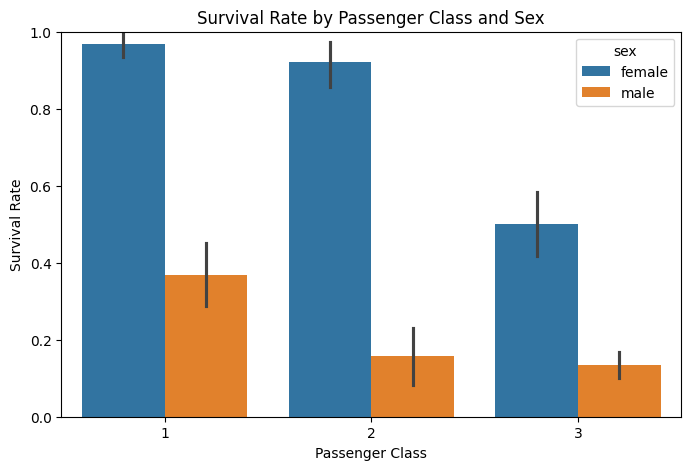

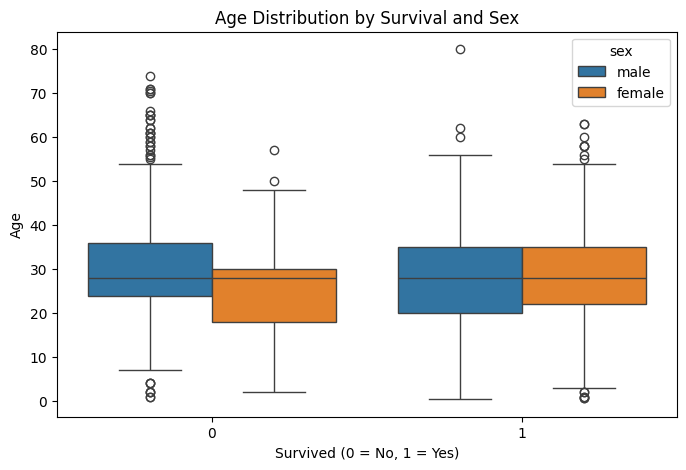

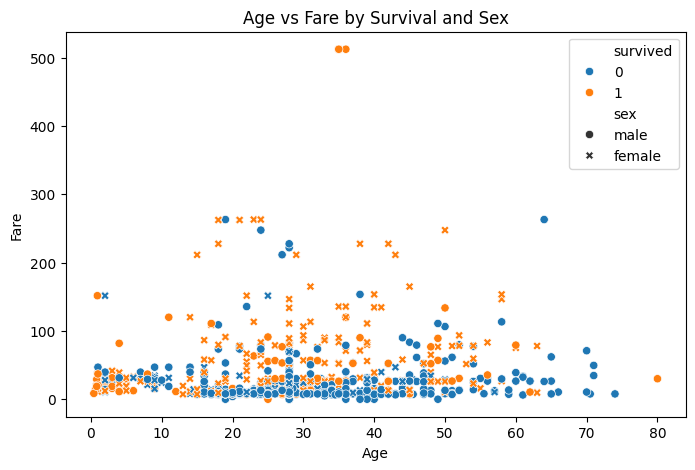

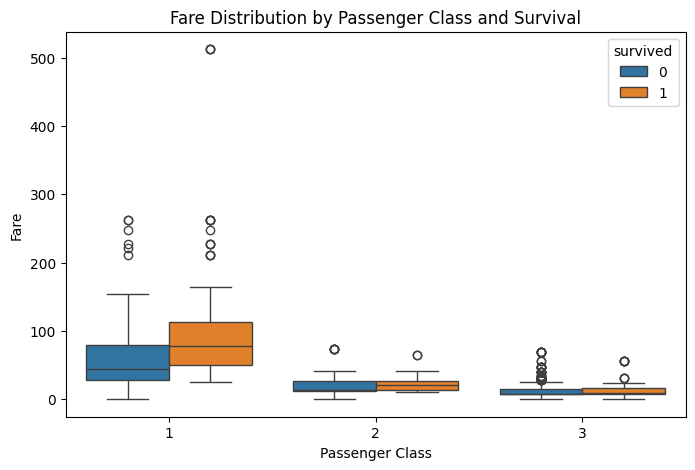

In [9]:

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="pclass", y="survived", hue="sex")
plt.title("Survival Rate by Passenger Class and Sex")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()



plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="survived", y="age", hue="sex")
plt.title("Age Distribution by Survival and Sex")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.show()



plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="sex"
)
plt.title("Age vs Fare by Survival and Sex")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()



plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="pclass", y="fare", hue="survived")
plt.title("Fare Distribution by Passenger Class and Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

## Multivariate Data Story – Interpretations

### Chart 1: Survival Rate by Passenger Class and Sex

Survival rates were generally higher for females than males across all passenger classes. First-class passengers had better survival outcomes than second- and third-class passengers. This suggests that both sex and passenger class were important factors associated with survival.

### Chart 2: Age Distribution by Survival and Sex

The age distributions show differences between survivors and non-survivors across males and females. Female survivors were present across a broad range of ages, while male survival was generally lower. Age appears to have some relationship with survival, although sex shows a stronger separation.

### Chart 3: Age vs Fare by Survival and Sex

The scatter plot shows that passengers who paid higher fares were more concentrated in the higher passenger classes, where survival was generally better. Survival patterns also differ between males and females across age and fare levels. This supports the idea that socioeconomic position and sex jointly influenced survival.

### Chart 4: Fare Distribution by Passenger Class and Survival

First-class passengers paid substantially higher fares than passengers in second and third class. Within passenger classes, survivors generally had higher fare distributions, especially in first class. This suggests that fare, which is related to passenger class and socioeconomic position, was associated with survival.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ["pclass","age","sibsp","parch","fare"]
cat_cols = ["sex","embarked"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]), cat_cols)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Three classifiers created successfully.")

Three classifiers created successfully.


In [15]:


X_train = df.drop(columns="survived").loc[X_train.index]
X_test = df.drop(columns="survived").loc[X_test.index]

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (711, 12)
Test: (178, 12)


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    results.append([name,
                    accuracy_score(y_test, pred),
                    precision_score(y_test, pred),
                    recall_score(y_test, pred),
                    f1_score(y_test, pred),
                    roc_auc_score(y_test, prob)])

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1","AUC"]
)

display(results_df.round(3))

,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.783,0.691,0.734,0.861
1,Decision Tree,0.770,0.690,0.721,0.705,0.754
2,Random Forest,0.820,0.781,0.735,0.758,0.818


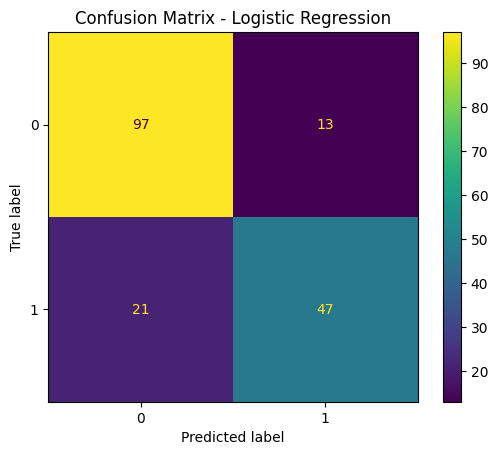

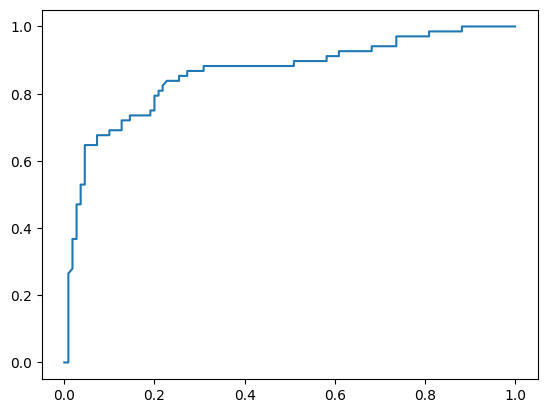

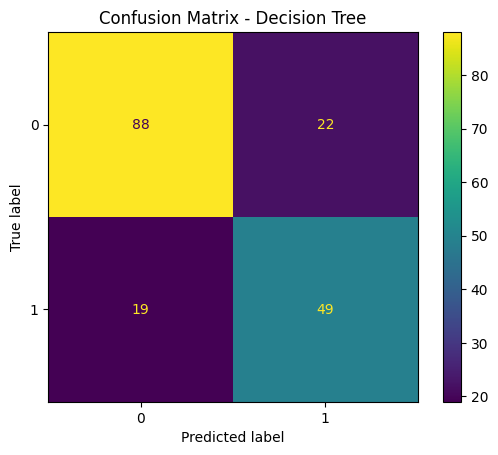

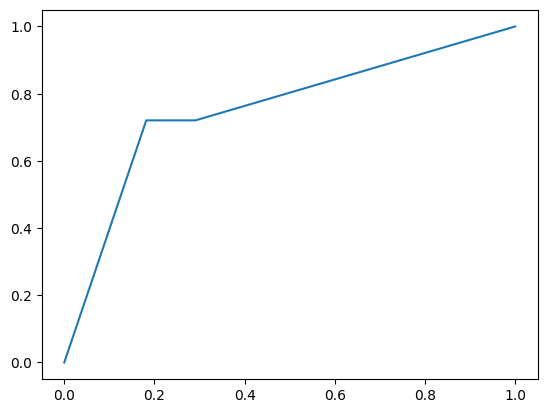

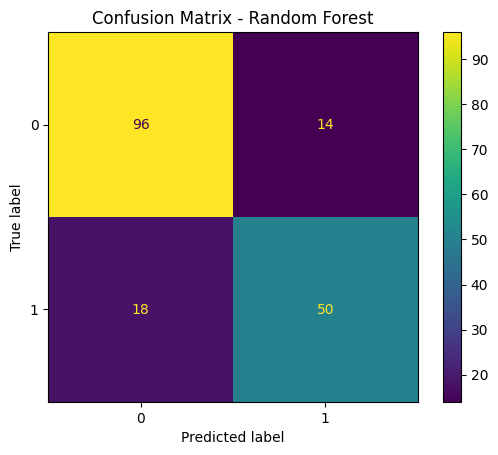

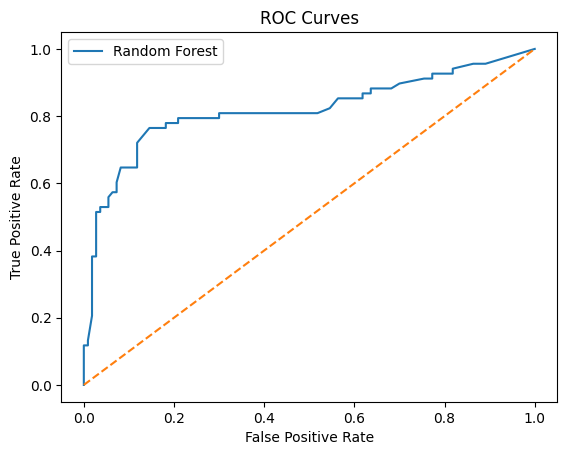

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]

    ConfusionMatrixDisplay.from_predictions(y_test, pred)
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    preprocessor.fit_transform(X_train),
    y_train
)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())


rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

X_test_transformed = preprocessor.transform(X_test)

pred_smote = rf_smote.predict(X_test_transformed)

print("\nRandom Forest with SMOTE:")
print("Accuracy :", round(accuracy_score(y_test, pred_smote), 3))
print("Precision:", round(precision_score(y_test, pred_smote), 3))
print("Recall   :", round(recall_score(y_test, pred_smote), 3))
print("F1 Score :", round(f1_score(y_test, pred_smote), 3))

Before SMOTE: {0: 439, 1: 272}
After SMOTE: {1: 439, 0: 439}

Random Forest with SMOTE:
Accuracy : 0.792
Precision: 0.746
Recall   : 0.691
F1 Score : 0.718


In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline


rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        oob_score=True
    ))
])


param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10],
    "model__min_samples_split": [2, 5]
}


grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 3))


best_rf = grid_search.best_estimator_.named_steps["model"]

print("\nOOB Score:")
print(round(best_rf.oob_score_, 3))

Best Parameters:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best Cross-Validation F1 Score:
0.745

OOB Score:
0.824


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

reg_data = df.dropna(subset=["fare"]).copy()

X_reg = reg_data[["age", "pclass", "sibsp", "parch"]]
y_reg = reg_data["fare"]

X_reg = pd.get_dummies(X_reg, columns=["pclass"], drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

fare_pred = reg_model.predict(X_test_reg)

print("Fare Regression Results:")
print("MAE :", round(mean_absolute_error(y_test_reg, fare_pred), 3))
print("RMSE:", round(mean_squared_error(y_test_reg, fare_pred) ** 0.5, 3))
print("R2  :", round(r2_score(y_test_reg, fare_pred), 3))

Fare Regression Results:
MAE : 16.423
RMSE: 40.844
R2  : 0.375


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import joblib


best_pred = grid_search.predict(X_test)
best_prob = grid_search.predict_proba(X_test)[:, 1]

tuned_rf_results = {
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, best_pred),
    "Precision": precision_score(y_test, best_pred),
    "Recall": recall_score(y_test, best_pred),
    "F1": f1_score(y_test, best_pred),
    "AUC": roc_auc_score(y_test, best_prob)
}

comparison_df = pd.concat([
    results_df,
    pd.DataFrame([tuned_rf_results])
], ignore_index=True)

print("Final Model Comparison:")
display(comparison_df.round(3))

print("\nBest Model: Tuned Random Forest")
print("OOB Score:", round(best_rf.oob_score_, 3))


joblib.dump(grid_search.best_estimator_, "titanic_best_pipeline.joblib")

print("\nComplete pipeline saved successfully:")
print("titanic_best_pipeline.joblib")

Final Model Comparison:


,Model,Accuracy,Precision,Recall,F1,AUC
0,Logistic Regression,0.809,0.783,0.691,0.734,0.861
1,Decision Tree,0.770,0.690,0.721,0.705,0.754
2,Random Forest,0.820,0.781,0.735,0.758,0.818
3,Tuned Random Forest,0.803,0.800,0.647,0.715,0.822



Best Model: Tuned Random Forest
OOB Score: 0.824

Complete pipeline saved successfully:
titanic_best_pipeline.joblib


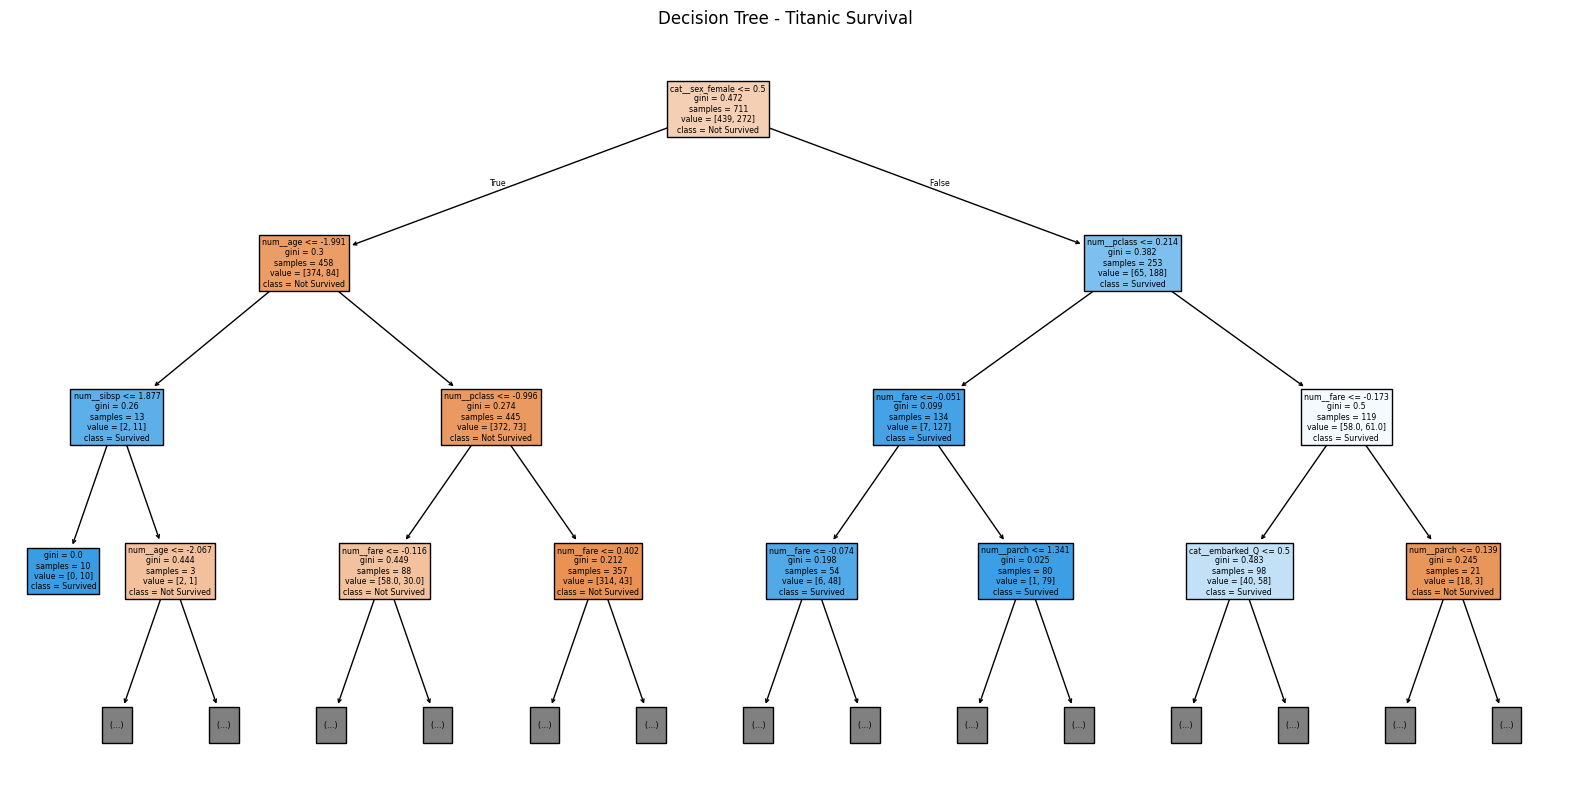

In [23]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


dt_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

dt_pipeline.fit(X_train, y_train)


feature_names = dt_pipeline.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(20, 10))

plot_tree(
    dt_pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree - Titanic Survival")
plt.show()

In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline - preprocessing + model
baseline_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

baseline_pipe.fit(X_train, y_train)
pred_baseline = baseline_pipe.predict(X_test)

# Class Weight = Balanced
balanced_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

balanced_pipe.fit(X_train, y_train)
pred_balanced = balanced_pipe.predict(X_test)

# Transform training data only for SMOTE
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_transformed, y_train
)

smote_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

smote_model.fit(X_train_smote, y_train_smote)
pred_smote = smote_model.predict(X_test_transformed)

# Comparison table
comparison = pd.DataFrame({
    "Method": ["Baseline", "Class Weight Balanced", "SMOTE"],
    "Precision": [
        precision_score(y_test, pred_baseline),
        precision_score(y_test, pred_balanced),
        precision_score(y_test, pred_smote)
    ],
    "Recall": [
        recall_score(y_test, pred_baseline),
        recall_score(y_test, pred_balanced),
        recall_score(y_test, pred_smote)
    ],
    "F1": [
        f1_score(y_test, pred_baseline),
        f1_score(y_test, pred_balanced),
        f1_score(y_test, pred_smote)
    ]
})

print("Class balance:")
print(y_train.value_counts().to_dict())

print("\nImbalance Handling Comparison:")
display(comparison.round(3))

Class balance:
{0: 439, 1: 272}

Imbalance Handling Comparison:


,Method,Precision,Recall,F1
0,Baseline,0.781,0.735,0.758
1,Class Weight Balanced,0.769,0.735,0.752
2,SMOTE,0.746,0.691,0.718


### Imbalance Handling Conclusion

The dataset is moderately imbalanced, with more non-survivors than survivors.
The baseline Random Forest achieved the highest F1 score of 0.758.
Class-weight balancing gave a similar result, while SMOTE produced a lower F1 score of 0.718.
Therefore, for this dataset, the baseline approach performed best among the three tested strategies.

R2: 0.375
Adjusted R2: 0.357


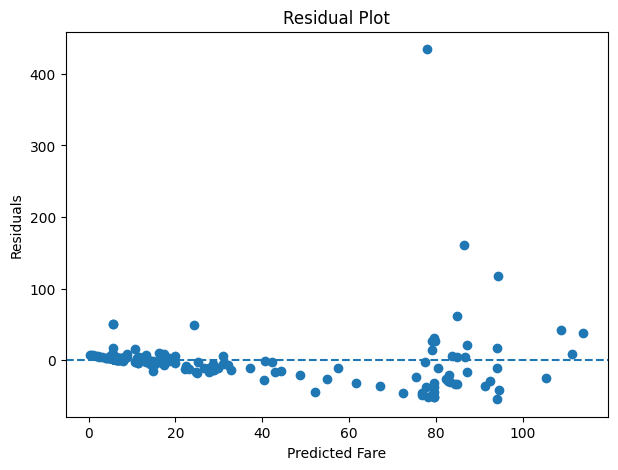

In [26]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

n = len(y_test_reg)
p = X_test_reg.shape[1]

r2 = r2_score(y_test_reg, fare_pred)
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

residuals = y_test_reg - fare_pred

print("R2:", round(r2, 3))
print("Adjusted R2:", round(adjusted_r2, 3))

plt.figure(figsize=(7,5))
plt.scatter(fare_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Regression Interpretation

The regression model achieved an MAE of 16.423, RMSE of 40.844, R² of 0.375, and Adjusted R² of 0.357.
The residual plot shows a non-random and increasing spread of residuals at higher predicted fares, indicating heteroscedasticity.

### Final Model Recommendation

Random Forest is recommended for deployment because it achieved the highest baseline F1 score of 0.758 and accuracy of 0.820.
Its AUC of 0.818 also indicates good ability to distinguish survivors from non-survivors.
The tuned Random Forest achieved an AUC of 0.822, although its F1 score was slightly lower at 0.715.
Therefore, the Random Forest model provides the best overall balance of classification performance for this dataset.